In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data/spotify_cleaned.csv")

In [2]:
print(df.shape)

df.head()

(4692, 24)


,energy,tempo,danceability,playlist_genre,loudness,liveness,valence,track_artist,time_signature,speechiness,...,track_album_release_date,instrumentalness,mode,key,duration_ms,acousticness,playlist_subgenre,popularity_group,release_year,duration_min
0,0.592,157.969,0.521,pop,-7.777,0.122,0.535,"Lady Gaga, Bruno Mars",3.0,0.0304,...,2024-08-16,0.0000,0.0,6.0,251668.0,0.3080,mainstream,High,2024.0,4.194467
1,0.507,104.978,0.747,pop,-10.171,0.117,0.438,Billie Eilish,4.0,0.0358,...,2024-05-17,0.0608,1.0,2.0,210373.0,0.2000,mainstream,High,2024.0,3.506217
2,0.808,108.548,0.554,pop,-4.169,0.159,0.372,Gracie Abrams,4.0,0.0368,...,2024-10-18,0.0000,1.0,1.0,166300.0,0.2140,mainstream,High,2024.0,2.771667
3,0.910,112.966,0.670,pop,-4.070,0.304,0.786,Sabrina Carpenter,4.0,0.0634,...,2024-08-23,0.0000,0.0,0.0,157280.0,0.0939,mainstream,High,2024.0,2.621333
4,0.783,149.027,0.777,pop,-4.477,0.355,0.939,"ROSÉ, Bruno Mars",4.0,0.2600,...,2024-10-18,0.0000,0.0,0.0,169917.0,0.0283,mainstream,High,2024.0,2.831950


In [3]:
df.describe()

,energy,tempo,danceability,loudness,liveness,valence,time_signature,speechiness,track_popularity,instrumentalness,mode,key,duration_ms,acousticness,release_year,duration_min
count,4692.000000,4692.000000,4692.000000,4692.000000,4692.000000,4692.000000,4692.000000,4692.000000,4692.000000,4692.000000,4692.000000,4692.000000,4.692000e+03,4692.000000,4692.000000,4692.000000
mean,0.584786,118.152715,0.624040,-9.294449,0.167435,0.478967,3.936275,0.102736,54.574169,0.203015,0.562234,5.222933,2.050255e+05,0.344746,2017.354859,3.417092
std,0.246346,28.484986,0.187816,7.180197,0.124330,0.257184,0.413466,0.101816,19.794377,0.353305,0.496165,3.582473,8.184752e+04,0.325773,10.099106,1.364125
min,0.000202,48.232000,0.058900,-48.069000,0.021000,0.029600,1.000000,0.021900,11.000000,0.000000,0.000000,0.000000,3.537500e+04,0.000004,1954.000000,0.589583
25%,0.440000,96.044750,0.527000,-10.289250,0.095575,0.271000,4.000000,0.038700,41.000000,0.000000,0.000000,2.000000,1.581892e+05,0.055475,2016.000000,2.636487
50%,0.632000,118.042500,0.655000,-7.191000,0.118000,0.479000,4.000000,0.056600,55.000000,0.000092,1.000000,5.000000,1.934975e+05,0.231000,2022.000000,3.224958
75%,0.774000,136.578250,0.760000,-5.330500,0.194250,0.685000,4.000000,0.120000,71.000000,0.214000,1.000000,8.000000,2.320000e+05,0.600000,2024.000000,3.866667
max,0.998000,241.426000,0.979000,1.318000,0.979000,0.987000,5.000000,0.927000,100.000000,0.991000,1.000000,11.000000,1.355260e+06,0.995000,2024.000000,22.587667


In [4]:
df["playlist_genre"].value_counts()

playlist_genre
electronic    583
pop           488
latin         420
hip-hop       392
ambient       359
rock          306
lofi          298
world         225
arabic        206
jazz          146
brazilian     138
gaming        128
classical     115
afrobeats      82
wellness       80
blues          76
turkish        71
punk           69
folk           66
indian         57
r&b            48
soul           44
metal          43
gospel         39
korean         34
funk           28
cantopop       27
j-pop          23
reggae         22
k-pop          17
indie          17
mandopop       14
soca           13
country        11
disco           7
Name: count, dtype: int64

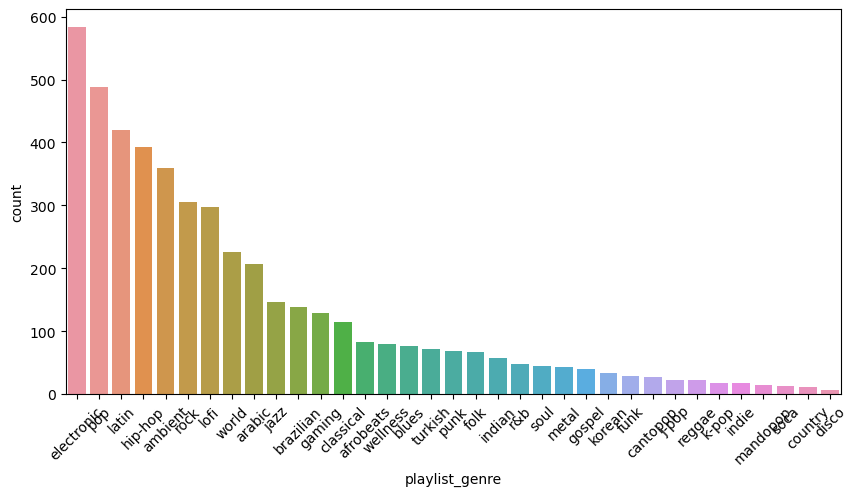

In [5]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="playlist_genre",
    order=df["playlist_genre"].value_counts().index
)

plt.xticks(rotation=45)
plt.show()

c:\Users\Duy  Thang\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


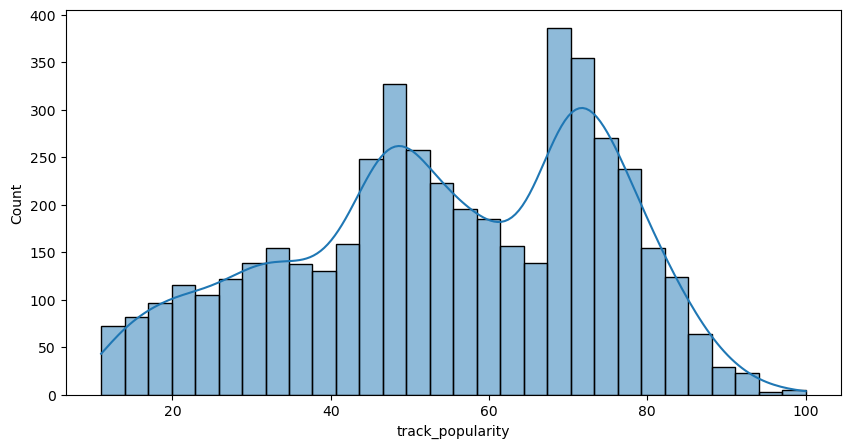

In [6]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["track_popularity"],
    bins=30,
    kde=True
)

plt.show()

c:\Users\Duy  Thang\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


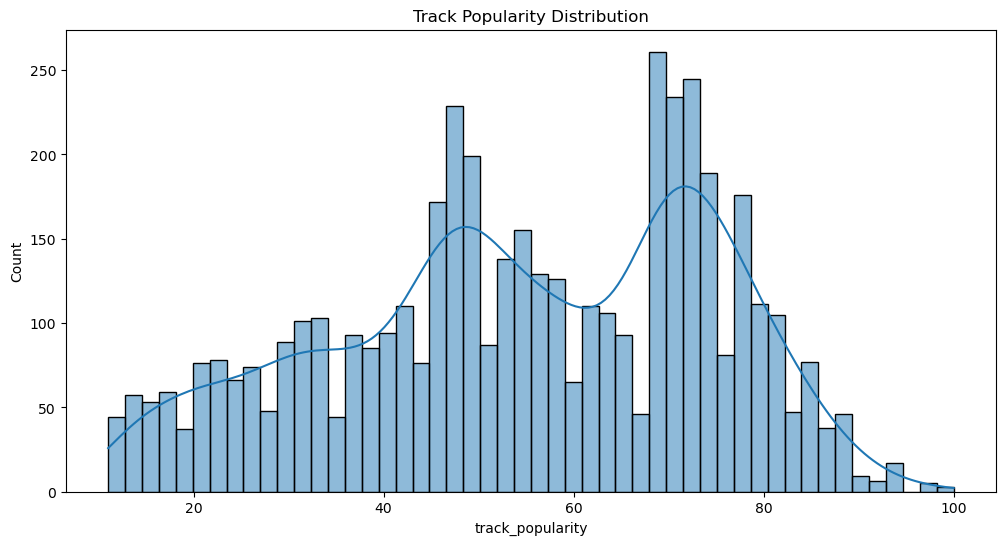

In [8]:
plt.figure(figsize=(12,6))

sns.histplot(
    df["track_popularity"],
    bins=50,
    kde=True
)

plt.title("Track Popularity Distribution")
plt.show()

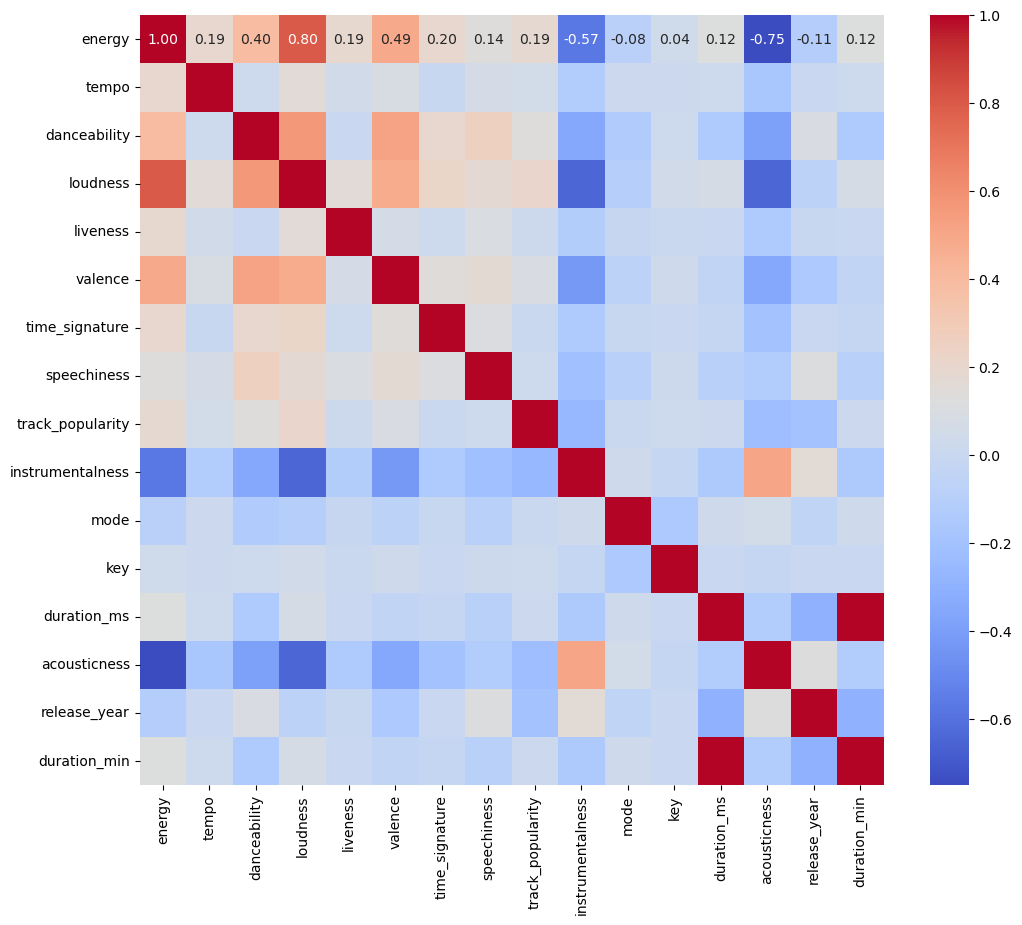

In [7]:
numeric_cols = df.select_dtypes(include=["int64","float64"])

corr = numeric_cols.corr()

plt.figure(figsize=(12,10))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.show()

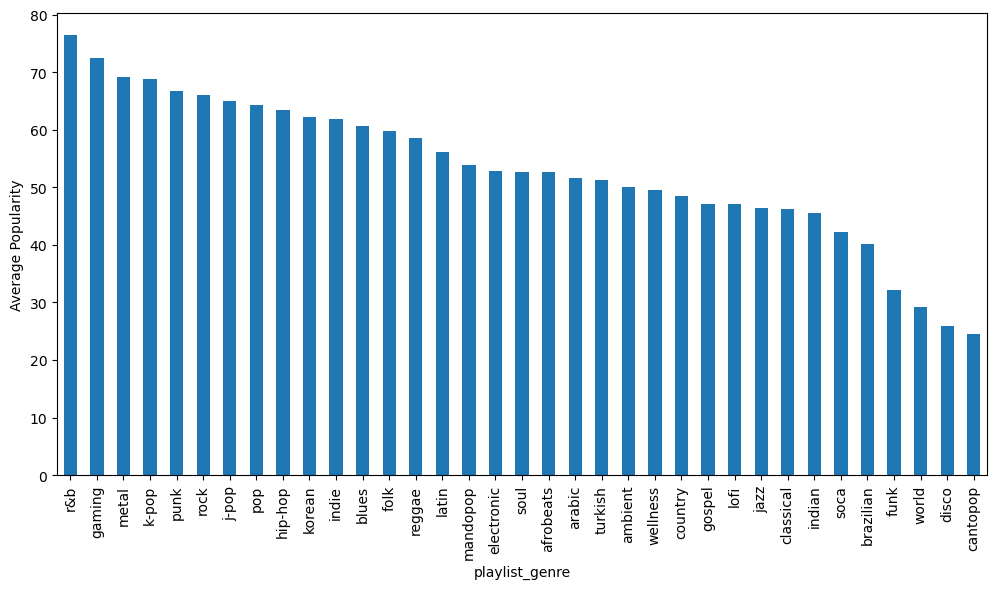

In [9]:
genre_pop = (
    df.groupby("playlist_genre")["track_popularity"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))
genre_pop.plot(kind="bar")
plt.ylabel("Average Popularity")
plt.show()

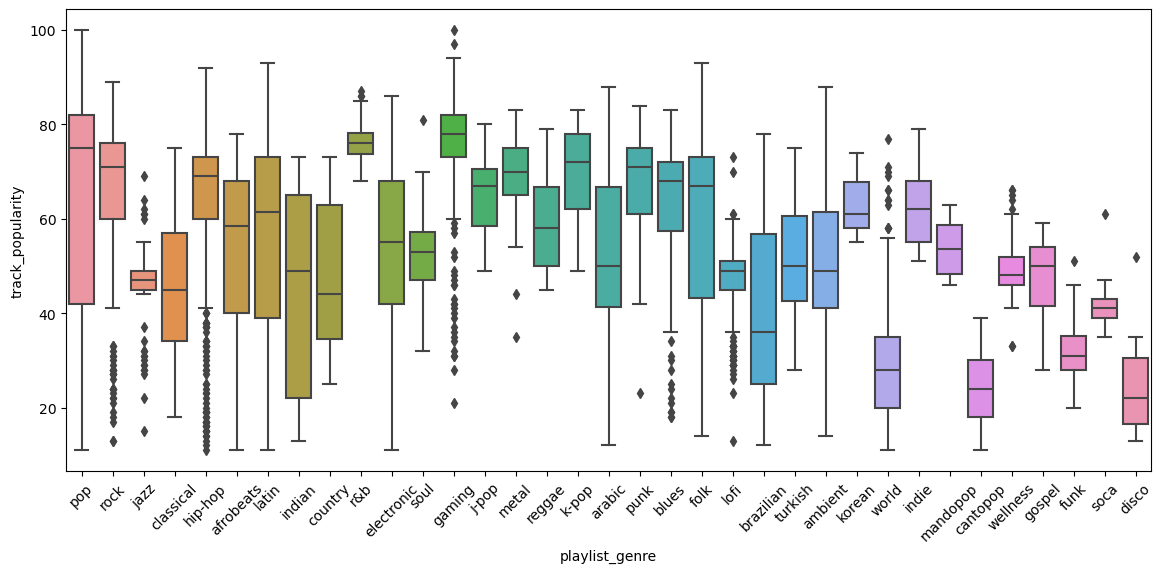

In [10]:
plt.figure(figsize=(14,6))

sns.boxplot(
    data=df,
    x="playlist_genre",
    y="track_popularity"
)

plt.xticks(rotation=45)
plt.show()

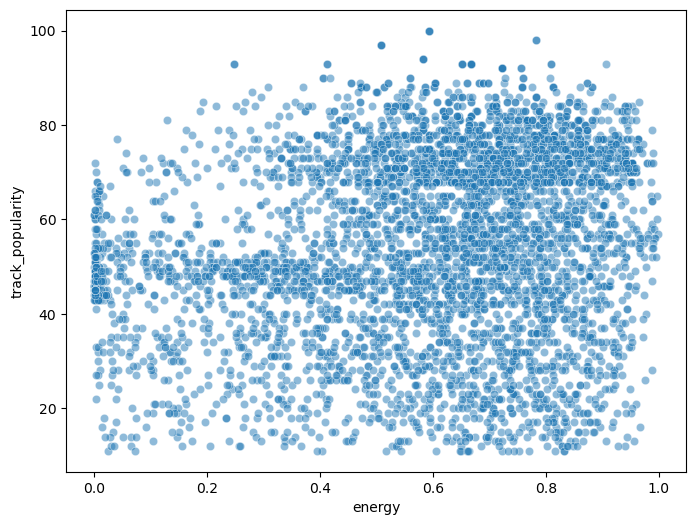

In [11]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="energy",
    y="track_popularity",
    alpha=0.5
)

plt.show()

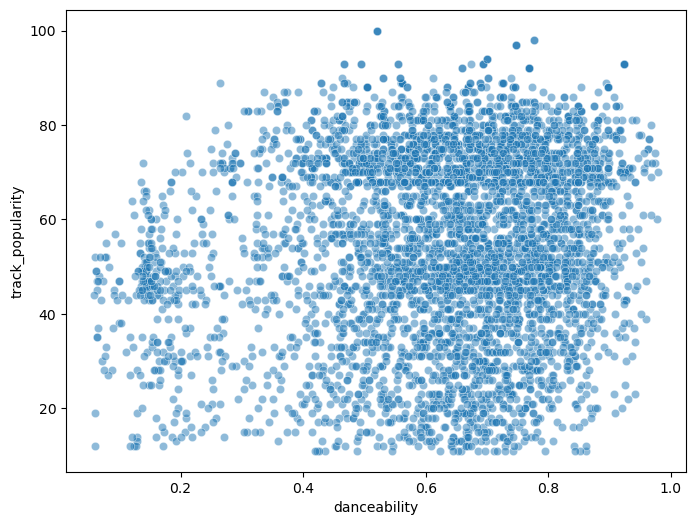

In [12]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="danceability",
    y="track_popularity",
    alpha=0.5
)

plt.show()